# How to train a neural network to flag spam

## Abstract

This is an AI pipeline that demonstrates the use of advanced AI tools used to classify messages as 'spam' or 'not spam'. We will be using the Kaggle dataset ([sms-spam-collection-dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset/data)) to train the model to classify different test messages. Python packages such as pandas, PyTorch, and numpy will be used to pre-process and train a model. We will use MatPlotLib to visualise the results as well as visual correlations between data. We will cleanse and tokenise our data so that it can be processed by our neural network.


## Learning Objectives

This tutorial will run through the following:
- Visualizing and understanding imbalanced datasets
- Finding inputs that correlate with the classification outcome
- Preprocessing text data by removing noisy data (stopwords, punctuation, links)
- Using pre-trained tokenizers (DistilBERT) to convert text into tensors
- Building a bidirectional LSTM neural network with PyTorch
- Training and evaluating a PyTorch model for binary classification
- Correctly classifying whether something is 'spam' or 'ham' (not spam)

## Tutorials used

The referred tutorials are at the end of this tutorial.

### Pros vs Cons of Tutorials

| Tutorial | Pros | Cons |
|----------|------|------|
| **[1] NLP GloVe, BERT, TF-IDF, LSTM Explained** | Explained the ins and outs of spam classification and preprocessing. Great graphics which I implemented in my tutorial. | Uses TensorFlow instead of PyTorch (required for coursework). |
| **[2] SMS Spam Classification with BERT** | Explained tokenization very well. Introduced HuggingFace AutoTokenizer which simplified complexity. | Did not train the neural network using PyTorch; used HuggingFace transformers package instead. |
| **[3] Text Classification by Hugging Face** | Very useful for understanding how tokenization and the tokenizer work. | Same as tutorial [2] - does not use PyTorch for training. |
| **[4] Medium Text Classification Tutorial** | Demonstrated how to build a custom PyTorch text classifier with custom data. Helpful for understanding the full training loop. | Uses a different model architecture (not LSTM-based) and different tokenization approach. |
| **[5] HuggingFace Text Classification with PyTorch** | Combined HuggingFace tokenizers with PyTorch training, which is exactly what this tutorial needed. | More complex setup than necessary for a simple spam classifier. |
| **[6] Introduction to RNNs** | Provided foundational understanding of how RNNs and LSTMs work conceptually. | Theoretical overview only - no practical code implementation provided. |

## Table of Contents
1. [Importing dataset](#1-importing-dataset)
2. [Label distribution](#2-label-distribution)
3. [Find correlation between length of message and label](#3-find-correlation-between-length-of-message-and-label)
   - 3.1. [Normalized as the dataset is imbalanced](#31-normalized-as-the-dataset-is-imbalanced)
4. [Preprocessing data](#4-preprocessing-data)
   - 4.1. [Text cleaning](#41-text-cleaning)
   - 4.2. [Splitting training and testing data](#42-splitting-training-and-testing-data)
   - 4.3. [Normalizing message lengths](#43-normalizing-message-lengths)
   - 4.4. [Computing class weights for imbalanced data](#44-computing-class-weights-for-imbalanced-data)
5. [Hyperparameter Experiments](#5-hyperparameter-experiments)
   - 5.1. [Results Table](#51-results-table)
   - 5.2. [Training Loss Curves](#52-training-loss-curves)
   - 5.3. [Analysis](#53-analysis)
6. [Final Model Training](#6-final-model-training)
   - 6.1. [Testing final model](#61-testing-final-model)
   - 6.2. [Manually testing model](#62-manually-testing-model)
7. [References](#7-references)

## 1. Importing dataset

We will import the csv dataset and map the values of spam and ham to 1 and 0 respectively as this is a binary classification problem and so our RNN can map to a result easily without having to tokenize the output.

In [170]:
import pandas as pd

# Latin1 encoding 
df = pd.read_csv("./spam.csv", encoding='latin1')

# Remove any empty rows
df = df.dropna(how="any", axis=1)
df.columns = ["label","message"]
# Binary values for ham (0) and spam (1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 2. Label distribution

Before solving this classification issue by creating a model, we will look at the distribution of our dataset.

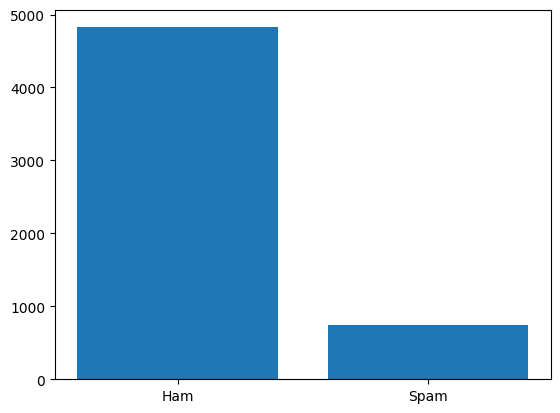

In [171]:
import matplotlib.pyplot as plt
import numpy as np

label_distribution = df.groupby("label")["label"].agg("count").values
label_distribution

x = np.array(["Ham","Spam"])
y = np.array(label_distribution)

plt.bar(x,y)
plt.show()

## 3. Find correlation between length of message and label

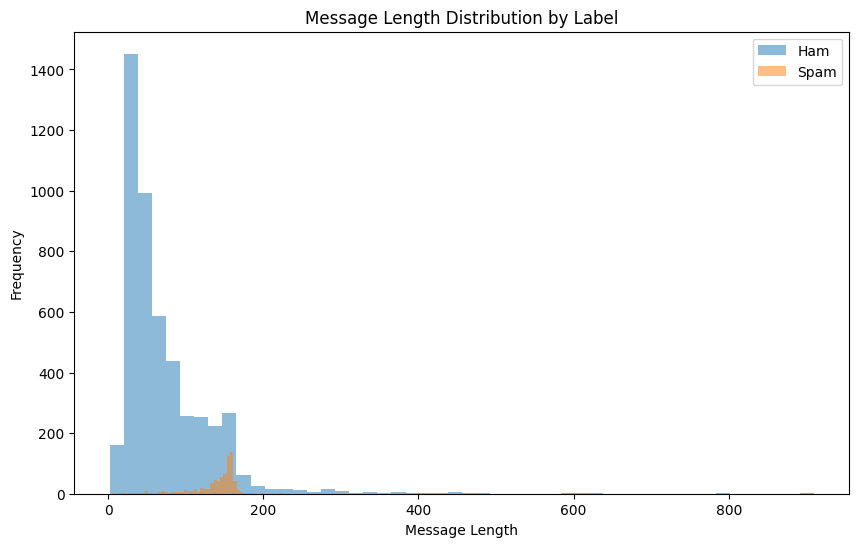

In [172]:
# Visualization approach inspired by source [1]
df['message_len'] = df['message'].astype(str).map(len)
df.head()

df.groupby("label")["message_len"].describe()

plt.figure(figsize=(10,6))

# Ham
plt.hist(df[df["label"] == 0]["message_len"], 
         bins=50, alpha=0.5, label="Ham")

# Spam
plt.hist(df[df["label"] == 1]["message_len"], 
         bins=50, alpha=0.5, label="Spam")

plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Message Length Distribution by Label")
plt.legend()
plt.show()

# source [1] https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained

### 3.1. Normalized as the dataset is imbalanced

As the dataset is imbalanced, we will normalize our dataset to make sure the high proportion on 'ham' does not affect our results by dominating the learning process.

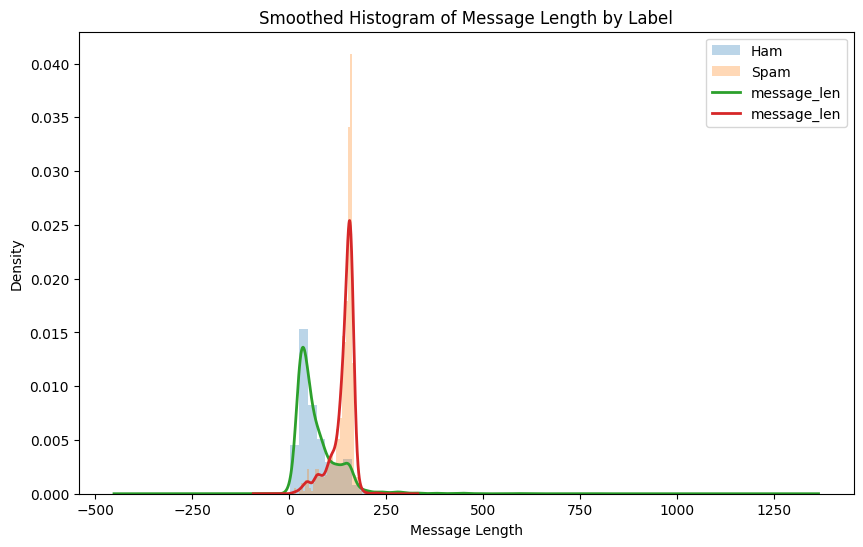

In [173]:
# Visualization approach inspired by source [1]
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ham = df[df["label"] == 0]["message_len"]
spam = df[df["label"] == 1]["message_len"]

# Histograms
plt.hist(ham, bins=40, density=True, alpha=0.3, label="Ham")
plt.hist(spam, bins=40, density=True, alpha=0.3, label="Spam")

# KDE lines
ham.plot(kind="kde", linewidth=2)
spam.plot(kind="kde", linewidth=2)

plt.xlabel("Message Length")
plt.ylabel("Density")
plt.title("Smoothed Histogram of Message Length by Label")
plt.legend()
plt.show()

# source [1] https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained

## 4. Preprocessing data

### 4.1. Text cleaning

In [174]:
# text cleaning as from source [1]

import re
import string

def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text


In [175]:
df['message_clean'] = df['message'].apply(clean_text)
df.head()

### end of source

# source [1] https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained

,label,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",111,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry in a wkly comp to win fa cup final...
3,0,U dun say so early hor... U c already then say...,49,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah i dont think he goes to usf he lives aroun...


In [176]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# stopwords processing as from source [1]

stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text
    
df['message_clean'] = df['message_clean'].apply(remove_stopwords)
df.head()

### end of source [1]

# source [1] https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\costjl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts m...
3,0,U dun say so early hor... U c already then say...,49,dun say early hor already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goes usf lives around though


### 4.2. Splitting training and testing data

In [177]:
from sklearn.model_selection import train_test_split

X = df["message_clean"]
y = df["label"]
lengths = df["message_len"]

X_train, X_test, y_train, y_test , len_train, len_test = train_test_split(
    X, 
    y,
    lengths,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


In [178]:
# Tokenization as from source [2], [3]
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased", use_fast=True)

### end of source [2], [3]
# source [2] https://www.kaggle.com/code/wesleyacheng/sms-spam-classification-with-bert?scriptVersionId=131649906&cellId=14
# source [3] https://huggingface.co/docs/transformers/preprocessing#tokenizer



train_encoded = tokenizer(
    list(X_train),
    padding = True,
    truncation=True,
    max_length=50,
    return_tensors="pt"
)

test_encoded = tokenizer(
    list(X_test),
    padding = True,
    truncation=True,
    max_length=50,
    return_tensors="pt"
)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

### 4.3. Normalizing message lengths

To ensure stable training, we normalize the message length feature using z-score normalization (standardization). This scales the values to have mean 0 and standard deviation 1, preventing the large range of message lengths from dominating the learning process.

In [179]:
# Convert to tensors
train_lengths = torch.tensor(len_train.values, dtype=torch.float32)
test_lengths = torch.tensor(len_test.values, dtype=torch.float32)

# Normalize using training set statistics (z-score normalization)
len_mean = train_lengths.mean()
len_std = train_lengths.std()

train_lengths_norm = (train_lengths - len_mean) / len_std
test_lengths_norm = (test_lengths - len_mean) / len_std

print(f"Original range: {train_lengths.min():.0f} - {train_lengths.max():.0f}")
print(f"Normalized range: {train_lengths_norm.min():.2f} - {train_lengths_norm.max():.2f}")
print(f"Mean: {len_mean:.2f}, Std: {len_std:.2f}")

Original range: 2 - 910
Normalized range: -1.31 - 13.88
Mean: 80.24, Std: 59.79


In [180]:
from torch.utils.data import TensorDataset, DataLoader

# Use normalized lengths in the dataset
train_dataset = TensorDataset(train_encoded["input_ids"], train_lengths_norm.unsqueeze(1), y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(test_encoded["input_ids"], test_lengths_norm.unsqueeze(1), y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32)

### 4.4. Computing class weights for imbalanced data

Since the dataset is imbalanced (~87% ham, ~13% spam), we compute class weights to give more importance to the minority class (spam) during training. This helps the model learn to correctly classify spam messages rather than just predicting 'ham' for everything. We use sklearn's `compute_class_weight` function as from source [8].

In [181]:
# Class weighting for imbalanced dataset as from source [8]
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train.values
)

# Convert to tensor for use in loss function
# For BCELoss, we need a weight for the positive class (spam)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]], dtype=torch.float32)

print(f"Class weights - Ham: {class_weights[0]:.4f}, Spam: {class_weights[1]:.4f}")
print(f"Positive class weight (for BCEWithLogitsLoss): {pos_weight.item():.4f}")

# source [8] - https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

Class weights - Ham: 0.5775, Spam: 3.7266
Positive class weight (for BCEWithLogitsLoss): 6.4532


In [182]:
# Custom SpamRNN architecture, inspired by concepts from sources [4], [5], [6]
# Dropout regularization as from source [7]
import torch.nn as nn

class SpamRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, dropout_rate=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout_rate)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2 + 1, 1)
        # Note: No sigmoid here - we output logits for use with BCEWithLogitsLoss
        # This is more numerically stable and allows us to use pos_weight for class imbalance

    def forward(self, x, msg_len):
        x = self.embedding(x)
        x = self.dropout(x)  # Apply dropout after embedding to prevent overfitting
        _, (hidden, _) = self.lstm(x)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)  # Apply dropout before final layer
        combined = torch.cat([hidden, msg_len], dim=1)
        out = self.fc(combined)
        return out.squeeze()  # Return logits, not probabilities

# source [7] - https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html

In [183]:
vocab_size = tokenizer.vocab_size

## 5. Hyperparameter Experiments

We will compare how different learning rates and number of epochs affect model performance. This helps us understand the impact of these hyperparameters on training.

In [184]:
def train_model(model, train_loader, epochs, lr, pos_weight=None):
    """Train a model with specified hyperparameters and return training history.
    
    Args:
        pos_weight: Weight for positive class (spam) to handle class imbalance
    """
    # Use BCEWithLogitsLoss with pos_weight for class imbalance handling
    if pos_weight is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    else:
        criterion = nn.BCEWithLogitsLoss()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'epoch': [], 'loss': []}
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, len_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            len_batch = len_batch.to(device)
            y_batch = y_batch.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(X_batch, len_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        history['epoch'].append(epoch + 1)
        history['loss'].append(avg_loss)
    
    return history

def evaluate_model(model, test_loader):
    """Evaluate model and return accuracy."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, len_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            len_batch = len_batch.to(device)
            y_batch = y_batch.to(device).float()
            
            outputs = model(X_batch, len_batch)
            # Apply sigmoid since model now outputs logits
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)
    
    return correct / total

In [185]:
# Define hyperparameter configurations to test
configs = [
    {'lr': 0.01, 'epochs': 5},
    {'lr': 0.001, 'epochs': 5},
    {'lr': 0.0001, 'epochs': 5},
    {'lr': 0.01, 'epochs': 10},
    {'lr': 0.001, 'epochs': 10},
    {'lr': 0.0001, 'epochs': 10},
]

# Store results
results = []
all_histories = {}
output_lines = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
output_lines.append(f"Using device: {device}")
output_lines.append(f"Using class weighting with pos_weight: {pos_weight.item():.4f}")
output_lines.append("=" * 50)

# Train each configuration with class weighting
for config in configs:
    lr = config['lr']
    epochs = config['epochs']
    
    # Create and train model with class weighting
    model = SpamRNN(vocab_size=vocab_size).to(device)
    history = train_model(model, train_loader, epochs, lr, pos_weight=pos_weight)
    accuracy = evaluate_model(model, test_loader)
    final_loss = history['loss'][-1]
    
    # Store results
    results.append({
        'Learning Rate': lr,
        'Epochs': epochs,
        'Final Loss': final_loss,
        'Accuracy': accuracy
    })
    all_histories[f"lr={lr}, epochs={epochs}"] = history
    
    # Collect output
    output_lines.append(f"lr={lr}, epochs={epochs} -> Loss: {final_loss:.4f}, Accuracy: {accuracy:.4f}")

output_lines.append("=" * 50)
output_lines.append("Training complete!")

# Print all at once
print("\n".join(output_lines))

Using device: cpu
Using class weighting with pos_weight: 6.4532
lr=0.01, epochs=5 -> Loss: 0.0267, Accuracy: 0.9794
lr=0.001, epochs=5 -> Loss: 0.1018, Accuracy: 0.9686
lr=0.0001, epochs=5 -> Loss: 0.4767, Accuracy: 0.9435
lr=0.01, epochs=10 -> Loss: 0.0085, Accuracy: 0.9812
lr=0.001, epochs=10 -> Loss: 0.0432, Accuracy: 0.9821
lr=0.0001, epochs=10 -> Loss: 0.2943, Accuracy: 0.9623
Training complete!


### 5.1. Results Table

In [186]:
# Display results as a table
results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].apply(lambda x: f"{x:.4f}")
results_df['Final Loss'] = results_df['Final Loss'].apply(lambda x: f"{x:.4f}")
results_df

,Learning Rate,Epochs,Final Loss,Accuracy
0,0.0100,5,0.0267,0.9794
1,0.0010,5,0.1018,0.9686
2,0.0001,5,0.4767,0.9435
3,0.0100,10,0.0085,0.9812
4,0.0010,10,0.0432,0.9821
5,0.0001,10,0.2943,0.9623


### 5.2. Training Loss Curves

Visualizing how the loss decreases over epochs for different configurations:

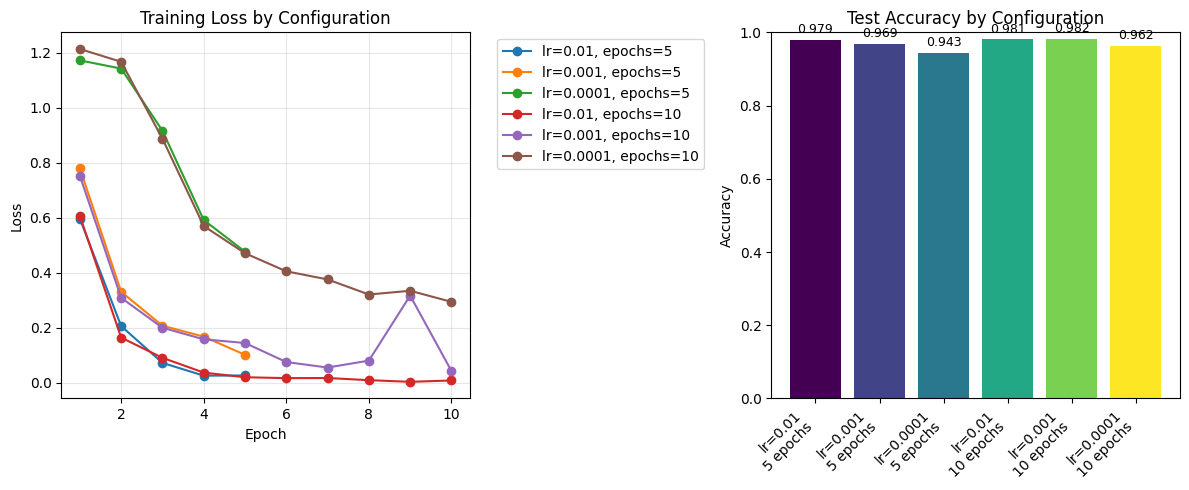

In [187]:
plt.figure(figsize=(12, 5))

# Plot 1: Loss curves for all configurations
plt.subplot(1, 2, 1)
for name, history in all_histories.items():
    plt.plot(history['epoch'], history['loss'], marker='o', label=name)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss by Configuration')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy comparison bar chart
plt.subplot(1, 2, 2)
configs_labels = [f"lr={r['Learning Rate']}\n{r['Epochs']} epochs" for r in results]
accuracies = [float(r['Accuracy']) for r in results]

colors = plt.cm.viridis(np.linspace(0, 1, len(configs_labels)))
bars = plt.bar(range(len(configs_labels)), accuracies, color=colors)
plt.xticks(range(len(configs_labels)), configs_labels, rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Test Accuracy by Configuration')
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 5.3. Analysis

From the experiments above, we can observe:
- **Learning rate impact**: Higher learning rates (0.01) starts at a low training error and eases its way towards 0 with stability, whilst lower learning rates (0.0001) start with a higher training error, converge more quickly at the start and do not seem to have a very stable performance.
- **Epochs impact**: More epochs generally lead to slightly better results as seen in the graph above representing the training loss curve but does not affect the training loss that much.
- **Best configuration**: The optimal balance seems to be 10 epochs with a 0.01 LR. More than 10 epochs seems to have a minimal impact to training loss. Although 0.001 LR with 10 epochs has the best results, it is very unstable as shown on the graph above.

## 6. Final Model Training

Based on the hyperparameter experiments, we now train our final model with the best configuration (LR: 0.01 Epochs: 10):

In [188]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpamRNN(vocab_size=vocab_size).to(device)

# Use BCEWithLogitsLoss with class weighting for imbalanced data
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Training with class weighting (pos_weight: {pos_weight.item():.4f})")

for epoch in range(10):
    model.train()
    epoch_loss = 0
    for X_batch, len_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        len_batch = len_batch.to(device)
        y_batch = y_batch.to(device).float()
        
        optimizer.zero_grad()
        outputs = model(X_batch, len_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Training with class weighting (pos_weight: 6.4532)
Epoch 1 Loss: 0.5054
Epoch 1 Loss: 0.5054
Epoch 2 Loss: 0.1392
Epoch 2 Loss: 0.1392
Epoch 3 Loss: 0.1465
Epoch 3 Loss: 0.1465
Epoch 4 Loss: 0.0991
Epoch 4 Loss: 0.0991
Epoch 5 Loss: 0.0172
Epoch 5 Loss: 0.0172
Epoch 6 Loss: 0.0116
Epoch 6 Loss: 0.0116
Epoch 7 Loss: 0.0105
Epoch 7 Loss: 0.0105
Epoch 8 Loss: 0.0073
Epoch 8 Loss: 0.0073
Epoch 9 Loss: 0.0228
Epoch 9 Loss: 0.0228
Epoch 10 Loss: 0.0155
Epoch 10 Loss: 0.0155


### 6.1. Testing final model

In [189]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, len_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        len_batch = len_batch.to(device)
        y_batch = y_batch.to(device).float()

        outputs = model(X_batch, len_batch)
        # Apply sigmoid since model outputs logits
        predictions = (torch.sigmoid(outputs) > 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9830


### 6.2. Manually testing model

In [190]:
# Example new message
new_message = "Hey how are you finding work today?"

# Tokenize like before
encoding = tokenizer(
    [new_message],
    padding="max_length",
    truncation=True,
    max_length=train_encoded["input_ids"].shape[1],
    return_tensors="pt"
)

input_ids = encoding["input_ids"].to(device)

# Compute message length and normalize using the same statistics from training
raw_len = len(new_message)
msg_len_norm = torch.tensor([[(raw_len - len_mean.item()) / len_std.item()]], dtype=torch.float32)

# Forward pass
model.eval()
with torch.no_grad():
    output = model(input_ids, msg_len_norm)
    # Apply sigmoid since model outputs logits
    probability = torch.sigmoid(output)
    prediction = (probability > 0.5).float()

# Interpret result
print(f"Spam probability: {probability.item():.4f}")
if prediction.item() == 1:
    print("Classification: Spam")
else:
    print("Classification: Ham")

Spam probability: 0.0001
Classification: Ham


## 7. References

### Dataset

The dataset comes from [Kaggle.com](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset/data)

It is a collection of SMS messages which are classified as 'spam' or 'ham' (not spam)

The dataset is found in the [spam.csv](./spam.csv)

### Tutorials

This tutorial uses and references external tutorials listed here:
- source [1] - NLP 📝 GloVe, BERT, TF-IDF, LSTM... 📝 Explained - https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained
- source [2] - SMS Spam Classification with BERT - https://www.kaggle.com/code/wesleyacheng/sms-spam-classification-with-bert/notebook
- source [3] - Text Classification by Hugging Face - https://huggingface.co/docs/transformers/en/tasks/sequence_classification
- source [4] - Medium text classification tutorial - https://medium.com/@spandey8312/text-classification-using-custom-data-and-pytorch-d88ba1087045
- source [5] - Hugging Face Text Classification Tutorial Using PyTorch - https://www.sabrepc.com/blog/Deep-Learning-and-AI/Hugging-Face-Text-Classification-Tutorial-PyTorch?srsltid=AfmBOoqAUEarB5oY4ROvAo9n-Lz1b6xLFydcpEuIY09cEA55InbrjGLe
- source [6] - Introduction to RNNs - https://www.geeksforgeeks.org/machine-learning/introduction-to-recurrent-neural-network/
- source [7] - PyTorch Dropout Documentation - https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html
- source [8] - Sklearn compute_class_weight Documentation - https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html